# Electrical stimulation fMRI: stitching and preprocessing

1. Convert the raw Bruker functional scans (same session and subject, acquired back-to-back with identical acquisition parameters) to NIfTI and concatenate them in the given order.
2. Motion-correct the stitched series once against a single reference volume (the middle volume of the whole series).
3. Draw the brain mask on the middle volume, compute the mean motion-corrected image and process the structural scan.

Enter the functional scan numbers in acquisition order. `scan_boundaries.csv` in the functional analysis folder records the volume range of each original scan.

Every step is skipped when its output already exists and is newer than its inputs, so the notebook can simply be run again. Tick *Force re-run* to recompute everything. The results go to the stitched folder (`func.nii.gz`, `mc_func.nii.gz`, masks) and to `<analysis folder name>` inside it (`mean_mc_func.nii.gz`, `session.json`). `session.json` is loaded by `mol_fMRI_electric_stim_analysis.ipynb`, which continues from here.

In [3]:
import importlib
import electric_stim_helpers, electric_stim_session
importlib.reload(electric_stim_helpers)  # picks up edits of the helper modules without restarting the kernel
importlib.reload(electric_stim_session)
from electric_stim_helpers import *
from electric_stim_session import *

In [4]:
def int_widget(value, desc):
    return widgets.IntText(value=value, description=desc, layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})


def print_selected_pipeline_steps():
    print("\nPIPELINE STEP SELECTION SUMMARY")
    print("-" * 40)
    for step in PIPELINE_STEPS:
        print(f"[{'✓' if checkboxes[step['key']].value else ' '}] {step['name']}")
    print("-" * 40)


def is_step_enabled(step_key):
    return checkboxes.get(step_key, None) and checkboxes[step_key].value


PIPELINE_STEPS = [
    {"name": "Bruker → NIfTI + Stitching", "key": "bruker_to_nifti"},
    {"name": "Motion Correction", "key": "motion_correction"},
    {"name": "Masking", "key": "masking_file"}]

checkboxes = {step["key"]: widgets.Checkbox(value=True, description=step["name"], indent=False) for step in PIPELINE_STEPS}

display(widgets.Box(list(checkboxes.values()), layout=widgets.Layout(display="flex", flex_flow="row wrap", align_items="flex-start", gap="10px")))

Box(children=(Checkbox(value=True, description='Bruker → NIfTI + Stitching', indent=False), Checkbox(value=Tru…

In [5]:
## Make sure what functions are selected to run in the pipeline
print_selected_pipeline_steps()

# Linux workstation mounts the data under /home, macOS under /Volumes
FMRI_ROOT = next(p for p in ("/home/pschmidt/fmri_analysis", "/Volumes/pschmidt/fmri_analysis") if os.path.isdir(p))

## Choosing the raw data that needs to be analysed
root_location = f"{FMRI_ROOT}/RawData"
selected_folder = FileChooser(root_location, layout=widgets.Layout(width='1080px'))
selected_folder.show_only_dirs = True
display(selected_folder)


PIPELINE STEP SELECTION SUMMARY
----------------------------------------
[✓] Bruker → NIfTI + Stitching
[✓] Motion Correction
[✓] Masking
----------------------------------------


FileChooser(path='/Volumes/pschmidt/fmri_analysis/RawData', filename='', title='', show_hidden=False, select_d…

In [6]:
in_path = Path(selected_folder.selected_path)
print(f"Our Raw Data is located in the path {in_path}")
subject_id = extract_subject_id(in_path)

# ---------- Common styles ----------
INPUT_LAYOUT = widgets.Layout(width="280px", flex="0 0 auto")
ROW_LAYOUT = widgets.Layout(width="100%", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e")
DESC_WIDTH = "220px"

# ---------- Widgets (KEEP REFERENCES) ----------
func_scan_numbers_entered = widgets.Text(value="", placeholder="e.g. 10, 11, 12", description="Functional Scans (in order):", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
struct_scan_number_entered = int_widget(10, "Structural Scan:")
mask_source_dir_entered = widgets.Text(value="", placeholder="optional", description="Reuse masks from folder:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})

row = widgets.HBox([func_scan_numbers_entered, struct_scan_number_entered], layout=ROW_LAYOUT)
analysis_name_entered = widgets.Text(value="analysis", description="Analysis folder name:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
force_rerun_entered = widgets.Checkbox(value=False, description="Force re-run of finished steps", indent=False)
row_masks = widgets.HBox([mask_source_dir_entered, analysis_name_entered, force_rerun_entered], layout=ROW_LAYOUT)
display(row, row_masks)

Our Raw Data is located in the path /Volumes/pschmidt/fmri_analysis/RawData/MMP9/WT_electric_stim/20260818_142038_RGRO_260818_0224_BL6_1367_WT_noAAV_1_1


In [7]:
func_scan_numbers = [s for s in re.split(r"[,\s]+", func_scan_numbers_entered.value.strip()) if s]
if len(func_scan_numbers) < 2:
    raise ValueError("Enter at least 2 functional scan numbers to stitch, e.g. '10, 11, 12'.")
func_scan_label = "-".join(func_scan_numbers)
struct_scan_number = str(struct_scan_number_entered.value)
mask_source_dir = mask_source_dir_entered.value.strip() or None

print_statement(f"Subject under analysis is {subject_id} for Functional Scans {', '.join(func_scan_numbers)} (stitched in this order) and Structural Scan Number {struct_scan_number}", bcolors.NOTIFICATION)

# # Parameters extraction for structural and functional files

params_struct = func_param_extract(Path(in_path) / struct_scan_number,export_env=True)
sequence_name_struct = params_struct["SequenceName"]

params_func = func_param_extract(Path(in_path) / func_scan_numbers[0],export_env=True)
sequence_name_func = params_func["SequenceName"]

# Stitching assumes identical acquisition parameters across scans
for num in func_scan_numbers[1:]:
    params_other = func_param_extract(Path(in_path) / num, export_env=False)
    if params_other["SequenceName"] != sequence_name_func or abs((params_other["VolTR"] or 0) - (params_func["VolTR"] or 0)) > 1e-3:
        print_statement(f"Scan {num} differs from scan {func_scan_numbers[0]} in sequence name or TR.", bcolors.FAIL)


# Setting up path for storing analysed data overall, structural data, functional data and processed functional data
# Analysed data overall
parts = list(in_path.parts)
parts[parts.index("RawData")] = "AnalysedData"
analysed_base = Path(*parts).parent
analysed_path = analysed_base / subject_id

# Structural and Functional data
analysed_struct_dir = Path(analysed_path) / f"{struct_scan_number}{sequence_name_struct}"
analysed_func_dir = Path(analysed_path) / f"stitched_{func_scan_label}_{sequence_name_func}"

# processed functional data: a fixed folder, so a later run (or the analysis notebook) finds the same files
analysis_dir = analysed_func_dir / (analysis_name_entered.value.strip() or "analysis")
analysis_dir.mkdir(parents=True, exist_ok=True)
electric_stim_session.FORCE_RERUN = force_rerun_entered.value

# path for raw structural and functional data 
path_raw_struct = os.path.join(in_path, struct_scan_number)
path_raw_func = ", ".join(os.path.join(in_path, num) for num in func_scan_numbers)

# Display of variables and paths in tabular form
var_vals = [
            ['Location of all Raw Data', 'root_location', root_location],
            ['Location of Raw Data to be analysed', 'in_path', in_path],
            ['Location of Raw Structural Data', 'path_raw_struct', path_raw_struct],
            ['Location of Raw Functional Data', 'path_raw_func', path_raw_func],
            ['Location of analysed structural data', 'analysed_struct_dir', analysed_struct_dir],
            ['Location of analysed functional data', 'analysed_func_dir', analysed_func_dir],
            ['Location of final processed functional data', 'analysis_dir', analysis_dir]
            ]

# pd.set_option('display.max_colwidth', 500)  # or 199
df = pd.DataFrame(var_vals, columns=['Purpose', 'Variable Name', 'Value'], index=['a', 'b', 'c', 'd', 'e', 'f', 'g'])
print(tabulate(df, headers='keys', tablefmt='psql'))

Subject under analysis is RGRO_260818_0224_BL6_1367 for Functional Scans 36, 31, 40 (stitched in this order) and Structural Scan Number 30
+----+---------------------------------------------+---------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|    | Purpose                                     | Variable Name       | Value                                                                                                                                                                                                                                                                                                                                                      

# Converting Functional Scans into NIFTI and Stitching them

In [9]:
print_statement(f"Analysed Data Path: {analysed_func_dir}", bcolors.NOTIFICATION)
analysed_func_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysed_func_dir)

if is_step_enabled("bruker_to_nifti"):
    print_header("Converting Bruker to NIFTI and stitching: Functional Data", bcolors.HEADER)

    stitched_file = analysed_func_dir / "func.nii.gz"

    if stitched_file.exists():
        print_statement("Stitched NIfTI file already exists. Skipping conversion and stitching.", bcolors.OKGREEN)
    else:
        scan_files = []
        for num in func_scan_numbers:
            work_dir = analysed_func_dir / "converted_raw" / f"scan_{num}"
            out_name = f"{num}_func_raw.nii.gz"
            if (work_dir / out_name).exists():
                print_statement(f"Scan {num} already converted. Skipping conversion.", bcolors.OKGREEN)
            else:
                bruker_scan_to_nifti(in_path, num, work_dir, out_name)
            scan_files.append(str((work_dir / out_name).resolve()))

        per_scan_volumes = [n_volumes(f) for f in scan_files]
        subprocess.run(["fslmerge", "-t", "func.nii.gz"] + scan_files, check=True)
        print_statement("[OK] Raw scans concatenated -> func.nii.gz", bcolors.OKGREEN)
        write_boundaries_csv(scan_files, per_scan_volumes, "scan_boundaries.csv")

else:
    print_statement("⏭️ Data Conversion Step not executed, May cause trouble in running further analysis", bcolors.NOTIFICATION)

input_name_for_next_step = "func"

Analysed Data Path: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI

**************************************************************************************************************************************
                                      Converting Bruker to NIFTI and stitching: Functional Data                                       
**************************************************************************************************************************************

Scan 36 already converted. Skipping conversion.
Converting raw Bruker scan 31 (/Volumes/pschmidt/fmri_analysis/RawData/MMP9/WT_electric_stim/20260818_142038_RGRO_260818_0224_BL6_1367_WT_noAAV_1_1/31) -> NIfTI...


/Users/pschmidt/miniforge3/envs/fmri/lib/python3.11/site-packages/brkraw/lib/loader.py:951: UserWarning: Unexpected version[VisuVersion];8
  warnings.warn('Unexpected version[VisuVersion];{}'.format(version), UserWarning)


NifTi file is generated... [RGRO_260818_0224_BL6_1367_1-31-1-functionalEPI-(E31)]
[OK] Raw Bruker scan 31 converted -> /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/converted_raw/scan_31/31_func_raw.nii.gz
Converting raw Bruker scan 40 (/Volumes/pschmidt/fmri_analysis/RawData/MMP9/WT_electric_stim/20260818_142038_RGRO_260818_0224_BL6_1367_WT_noAAV_1_1/40) -> NIfTI...


/Users/pschmidt/miniforge3/envs/fmri/lib/python3.11/site-packages/brkraw/lib/loader.py:951: UserWarning: Unexpected version[VisuVersion];8
  warnings.warn('Unexpected version[VisuVersion];{}'.format(version), UserWarning)


NifTi file is generated... [RGRO_260818_0224_BL6_1367_1-40-1-functionalEPI-(E40)]
[OK] Raw Bruker scan 40 converted -> /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/converted_raw/scan_40/40_func_raw.nii.gz
[OK] Raw scans concatenated -> func.nii.gz

**************************************************************************************************************************************
                                       Scan boundaries in stitched series (0-based, inclusive)                                        
**************************************************************************************************************************************

Scan 1: volumes 0-299 (300 vols) <- /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/converted_raw/scan_36/36_func_raw.nii.gz
Scan 2: volumes 300-2099 (1800 vols) <- /Volumes/pschmidt/fmri_

# Brain Mask

In [10]:
os.environ["FSLOUTPUTTYPE"] = "NIFTI_GZ"

tr = int(params_func["VolTR"])
n_vols = n_volumes("func.nii.gz")

# Middle volume of the whole stitched series: reference for motion correction and the image the mask is drawn on
run_step(["middle_vol.nii.gz"], ["func.nii.gz"], extract_middle_volume, "func.nii.gz", int(n_vols / 2), "middle_vol.nii.gz", 1)

mask_file = os.path.join(analysed_func_dir, "mask_mean_mc_func.nii.gz")

if is_step_enabled("masking_file"):
    # Only valid if the stitched scans share identical geometry with the mask source scan
    mask_src = Path(mask_source_dir) / "mask_mean_mc_func.nii.gz" if mask_source_dir else None
    if not os.path.exists(mask_file) and mask_src is not None and mask_src.exists():
        shutil.copyfile(mask_src, mask_file)
        print_statement(f"[OK] Reused mask from {mask_src}", bcolors.OKGREEN)

    if os.path.exists(mask_file):
        print_statement(f"Mask Image ({mask_file}) exists.", bcolors.OKGREEN)
    else:
        print_statement("Mask Image does not exist. Please create the mask and save it as mask_mean_mc_func.nii.gz", bcolors.FAIL)
        subprocess.run(["fsleyes", "middle_vol.nii.gz"])
        require_files([mask_file], "Save the brain mask as mask_mean_mc_func.nii.gz in the functional analysis folder.")
else:
    print_statement("⏭️ Masks not generated, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)

[OK] Intended Volumes extracted.
Mask Image does not exist. Please create the mask and save it as mask_mean_mc_func.nii.gz


wx._core.wxAssertionError: C++ assertion "nIndex < m_nCount" failed at ./include/wx/arrstr.h(227) in Item(): wxArrayString: index out of bounds
The above exception was the direct cause of the following exception:
SystemError: <class 'wx._core.PaintEvent'> returned a result with an exception set
Exception ignored while finalizing file <_io.TextIOWrapper name=4 mode='r' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
OSError: [Errno 9] Bad file descriptor
Exception ignored while finalizing file <_io.TextIOWrapper name=3 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor
Exception ignored while finalizing file <_io.TextIOWrapper name=6 mode='r' encoding='UTF-8'>:
Exception ignored in sys.unraisablehook: <built-in function unraisablehook>

# Applying Motion Correction in Raw Functional Data and Plotting Motion Parameters


**************************************************************************************************************************************
                           Applying Motion Correction on raw functional data and plotting motion parameters                           
**************************************************************************************************************************************

261005-17:16:32,237 nipype.interface INFO:
	 stderr 2026-10-05T17:16:32.237404:++ 3dvolreg: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
261005-17:16:32,238 nipype.interface INFO:
	 stderr 2026-10-05T17:16:32.237404:++ Authored by: RW Cox
261005-17:16:32,247 nipype.interface INFO:
	 stderr 2026-10-05T17:16:32.247318:++ Reading in base dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/middle_vol.nii.gz
261005-17:16:32,266 nipype.interface INFO:
	 stderr 2026-10-05T17:16:32.266760:++ Reading input datas

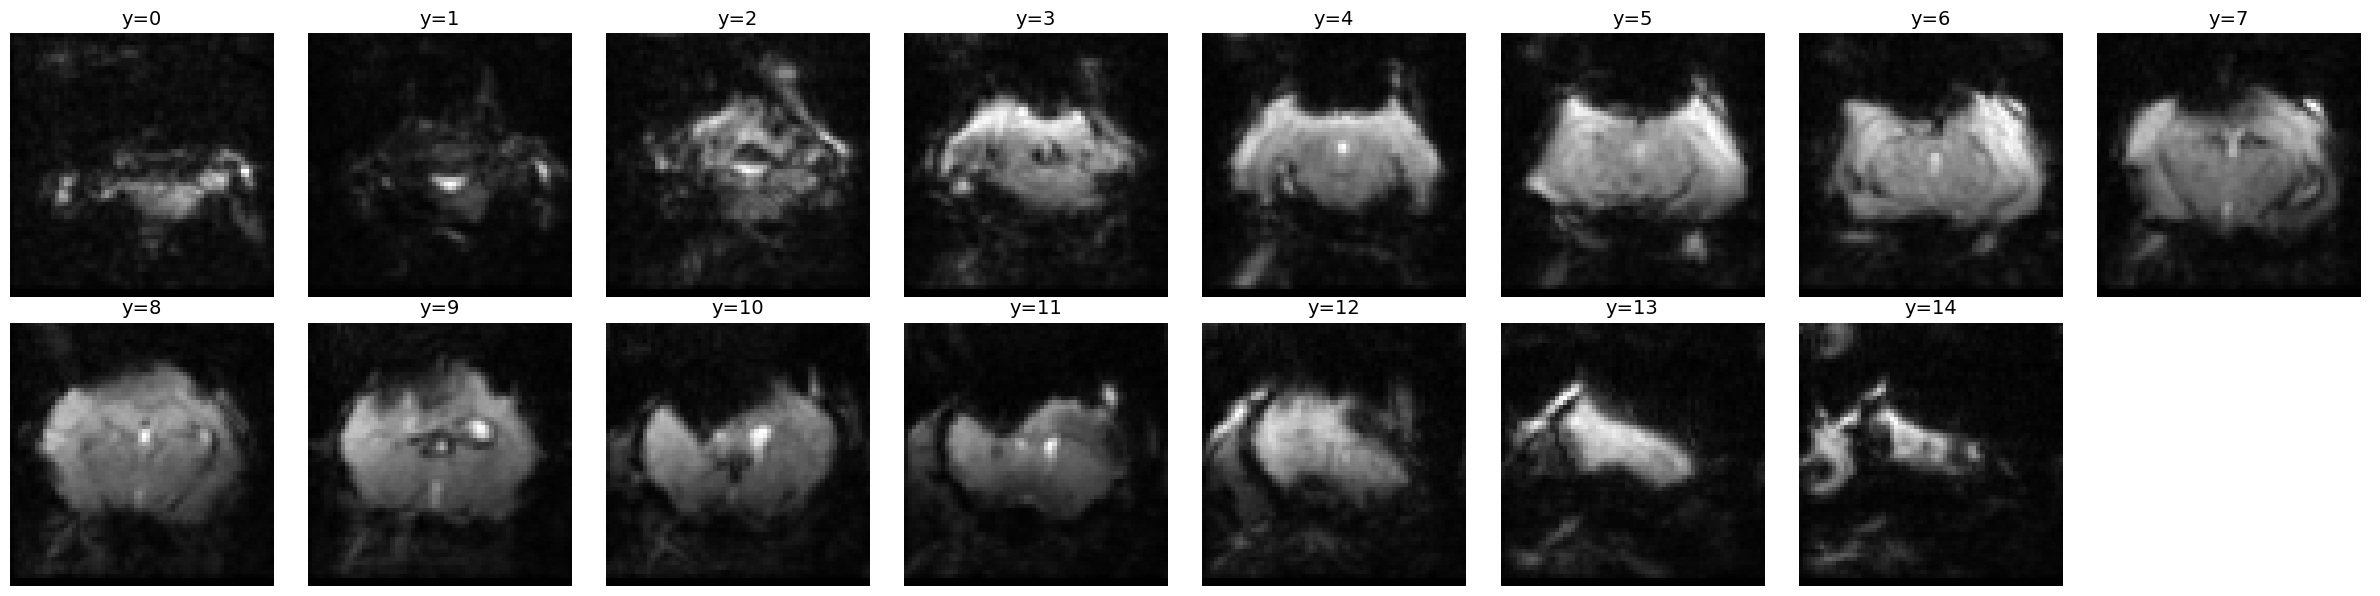

[INFO] Creating motion plots…


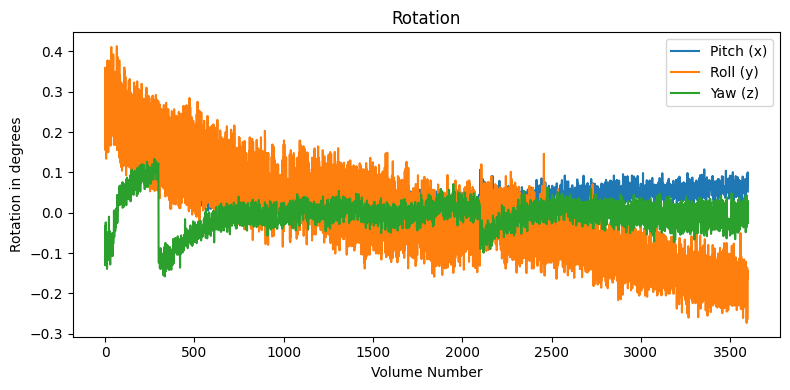

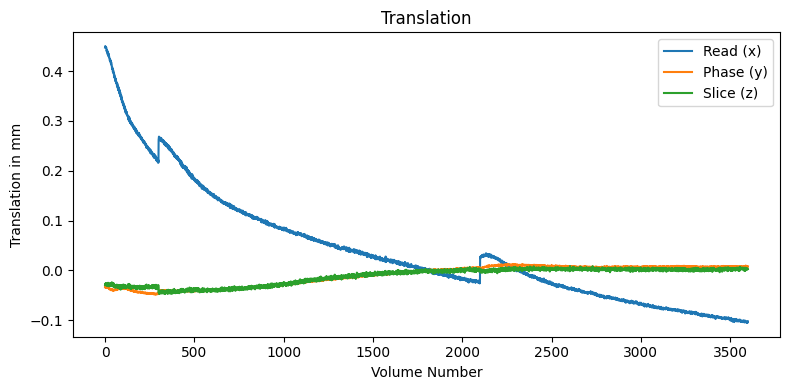

In [11]:
if is_step_enabled("motion_correction"):
    print_header("Applying Motion Correction on raw functional data and plotting motion parameters", bcolors.HEADER)

    if os.path.exists("mc_func.nii.gz"):
        print_statement("Motion Corrected functional data exists. Skipping motion correction.", bcolors.OKGREEN)
    else:
        motion_correction("middle_vol.nii.gz", "func.nii.gz", output_prefix="mc_func")

    # Display of the motion corrected image and motion parameters
    view_images("mc_func.nii.gz", cmap="gray")
    plot_motion_parameters("motion.1D")
else:
    print_statement("⏭️ Motion Correction not executed", bcolors.NOTIFICATION)

# Mean Motion-Corrected Image

In [12]:
print_statement(f"Analysis folder: {analysis_dir}", bcolors.NOTIFICATION)
analysis_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysis_dir)

mc_func_file = analysed_func_dir / "mc_func.nii.gz"
run_step(["mean_mc_func.nii.gz"], [mc_func_file], mean_image, str(mc_func_file), "mean_mc_func.nii.gz")

Analysis folder: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/analysis
[OK] Mean image saved -> mean_mc_func.nii.gz


'mean_mc_func.nii.gz'

# Converting Structural Data into NIFTI and Processing it

Analysed Data Path: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/30anatomy

**************************************************************************************************************************************
                                             Converting Bruker to NIFTI: Structural Data                                              
**************************************************************************************************************************************



/Users/pschmidt/miniforge3/envs/fmri/lib/python3.11/site-packages/brkraw/lib/loader.py:951: UserWarning: Unexpected version[VisuVersion];8
  warnings.warn('Unexpected version[VisuVersion];{}'.format(version), UserWarning)


NifTi file is generated... [RGRO_260818_0224_BL6_1367_1-30-1-anatomy-(E30)]
Fixing orientation to LPI
[OK] Bruker → NIFTI workflow completed.
Cleaning the structural image by manually creating mask
Please create a mask for the structural image and save it as mask_struct.nii.gz


wx._core.wxAssertionError: C++ assertion "nIndex < m_nCount" failed at ./include/wx/arrstr.h(227) in Item(): wxArrayString: index out of bounds
The above exception was the direct cause of the following exception:
SystemError: <class 'wx._core.PaintEvent'> returned a result with an exception set
Exception ignored while finalizing file <_io.TextIOWrapper name=6 mode='r' encoding='UTF-8'>:
Exception ignored in sys.unraisablehook: <built-in function unraisablehook>
Exception ignored while finalizing file <_io.TextIOWrapper name=5 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor
Exception ignored while finalizing file <_io.TextIOWrapper name=4 mode='r' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
Exception ignored while finalizing fil

[OK] Masked file saved → cleaned_struct.nii.gz


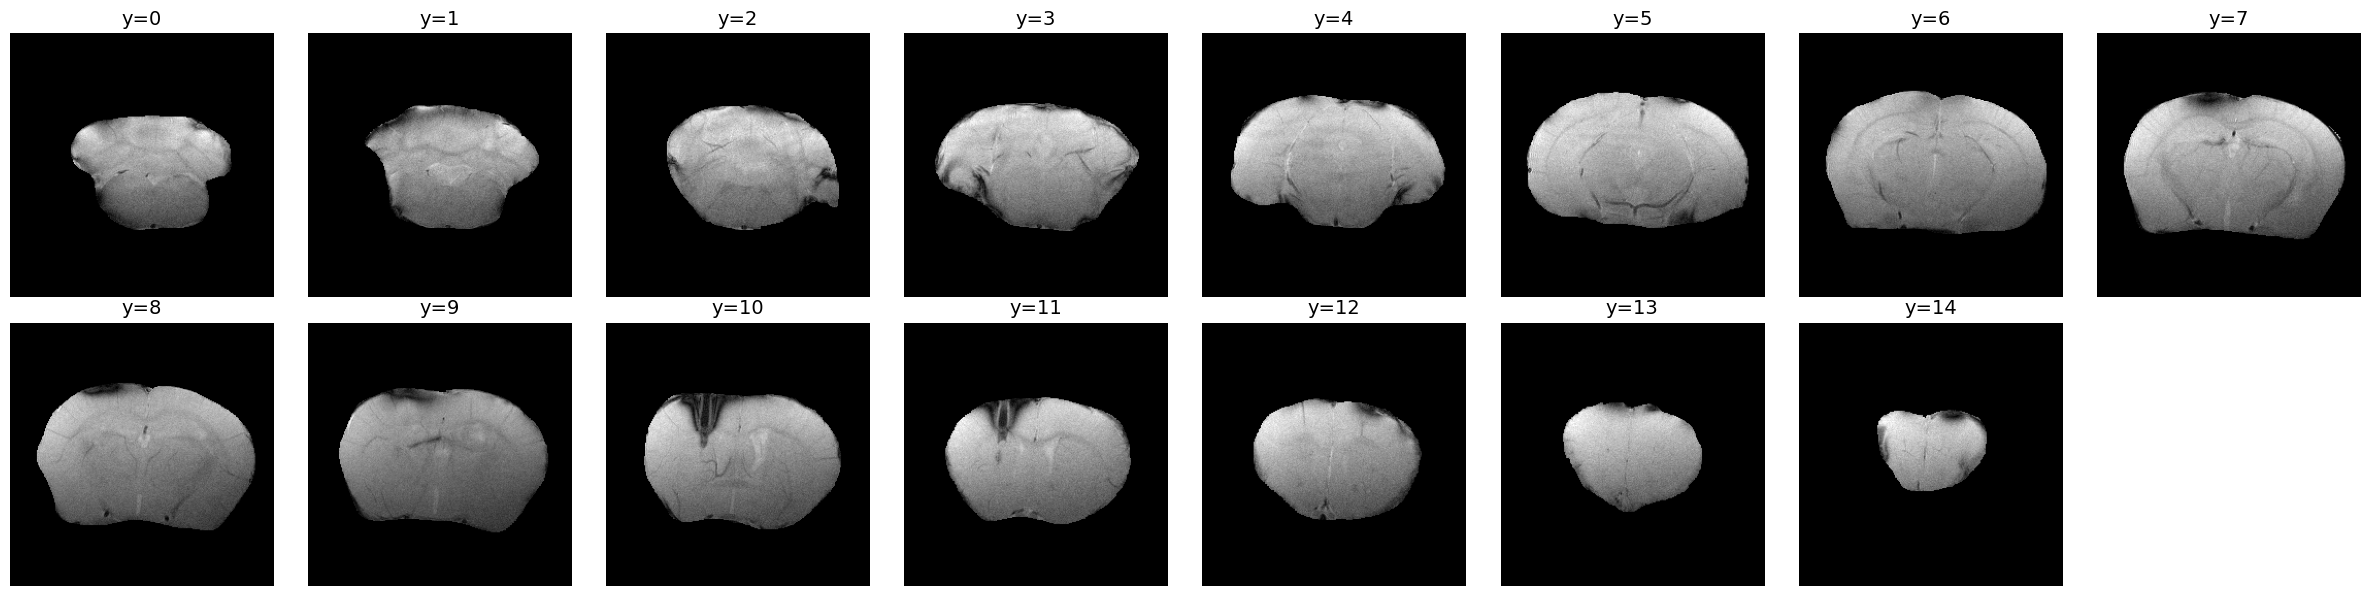

In [13]:
print_statement(f"Analysed Data Path: {analysed_struct_dir}", bcolors.NOTIFICATION)
analysed_struct_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysed_struct_dir)

if is_step_enabled("bruker_to_nifti"):
    print_header("Converting Bruker to NIFTI: Structural Data", bcolors.HEADER)

    nifti_file = analysed_struct_dir / "struct.nii.gz"
    if nifti_file.exists():
        print_statement("NIfTI file already exists. Skipping conversion.", bcolors.OKGREEN)
    else:
        bruker_to_nifti(in_path, struct_scan_number, "struct.nii.gz")

else:
    print_statement("⏭️ Data Conversion Step not executed, May cause trouble in running further analysis", bcolors.NOTIFICATION)


#Cleaning the structural image by masking it with a manually created mask

if is_step_enabled("masking_file"):
    print_statement("Cleaning the structural image by manually creating mask", bcolors.NOTIFICATION)
    
    if os.path.exists("cleaned_struct.nii.gz"):
        print_statement("Structural Image for Coregistration exists.", bcolors.OKGREEN)
    else:
        print_statement("Please create a mask for the structural image and save it as mask_struct.nii.gz", bcolors.NOTIFICATION)
        subprocess.run(["fsleyes", "struct.nii.gz", os.path.join(analysed_func_dir, "middle_vol.nii.gz")])
        masking_file("struct.nii.gz", "mask_struct.nii.gz", "cleaned_struct.nii.gz")

    structural_file_for_coregistration = os.path.join(analysed_struct_dir, "cleaned_struct.nii.gz")    
    view_images("cleaned_struct.nii.gz", cmap="gray")
    
    #Further shrinking the mask for structural image to get better coregistration results as structural image has high spatial resolution than functional image
    

else:
    print_statement("⏭️ Masks not generated, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)    
    structural_file_for_coregistration = os.path.join(analysed_struct_dir, "struct.nii.gz")    
    view_images("struct.nii.gz", cmap="gray")

In [14]:
# The stimulation analysis only needs the motion corrected data, the mask and the structural image
session_file = save_session(
    analysis_dir,
    in_path=in_path, subject_id=subject_id, func_scan_numbers=func_scan_numbers, struct_scan_number=struct_scan_number,
    analysed_func_dir=analysed_func_dir, analysed_struct_dir=analysed_struct_dir, analysis_dir=analysis_dir,
    mask_file=mask_file, structural_file_for_coregistration=structural_file_for_coregistration, tr=tr)
print_statement(f"[OK] Session saved: {session_file}", bcolors.OKGREEN)

[OK] Session saved: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/analysis/session.json
